In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from core import VmfHAC
from entity import DatasetManager, TextDatasets
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import skew

sys.setrecursionlimit(10000)

/Users/florian/dev/uni/python/vMF-HAC/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = DatasetManager("intfloat/multilingual-e5-large").get(TextDatasets.CLUSTREC_COVID)
k = np.unique(dataset.labels).shape[0]

Gamma: 0.001, Skew: 5.749010607122307


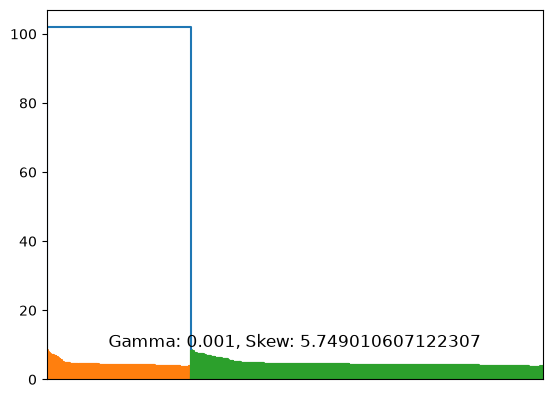

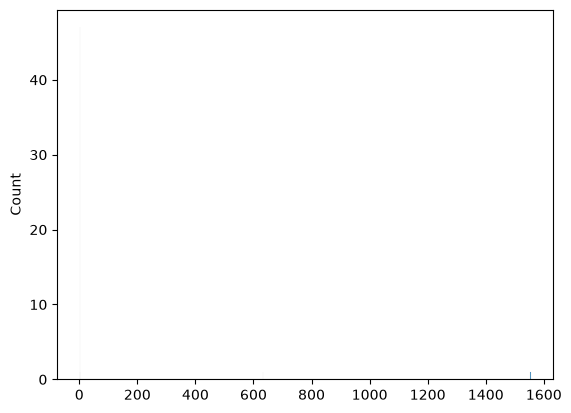

Gamma: 0.011090909090909092, Skew: 0.6452881771885556


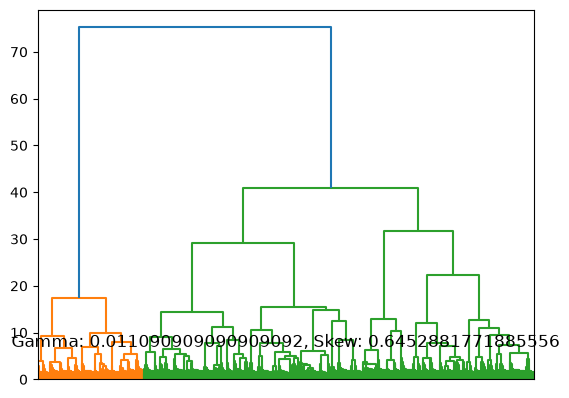

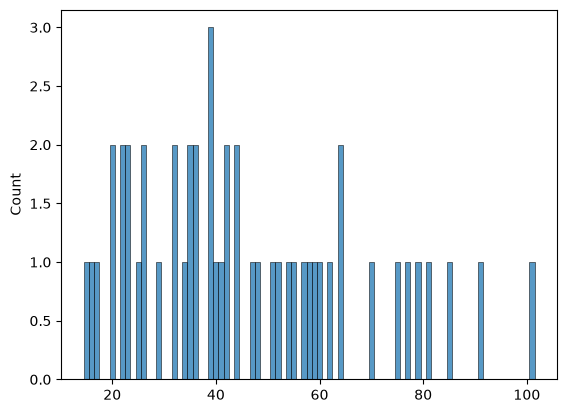

Gamma: 0.021181818181818184, Skew: 0.43107074798161993


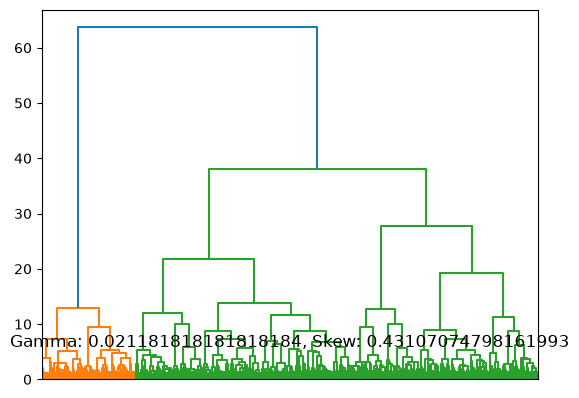

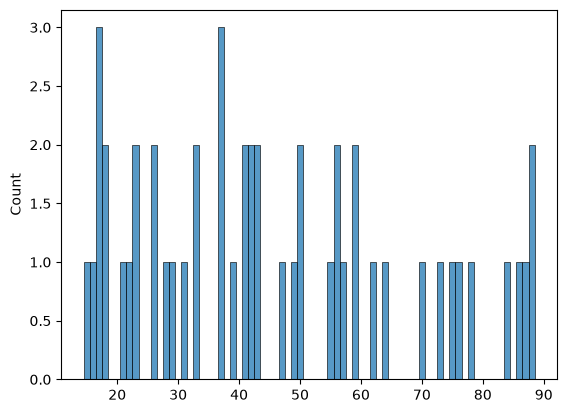

In [3]:
for gamma in np.linspace(0.001, 1.0, 100).tolist()[:3]:
    vmf = VmfHAC(n_clusters=k, gamma=gamma)
    labels = vmf.fit_predict(dataset.embeddings)
    cluster_counts = np.unique_counts(labels).counts
    print(f"Gamma: {gamma}, Skew: {skew(cluster_counts)}")
    dendrogram(vmf.linkage_matrix_, no_labels=True)
    plt.text(
        0.5,
        0.1,
        f"Gamma: {gamma}, Skew: {skew(cluster_counts)}",
        fontsize=12,
        ha="center",
        va="center",
        transform=plt.gca().transAxes,
    )
    plt.show()
    sns.histplot(cluster_counts, discrete=True)
    plt.show()